# Chapter 9 — Random Network (Erdős-Rényi G(n, p))
**Modeling Social Behavior** | Smaldino

---

This notebook translates the `RandomNetwork.nlogo` model into Python.

A **random network** (also called an Erdős-Rényi network) is built with the
G(n, p) algorithm:
- Start with `n` isolated nodes.
- For every possible pair of nodes (i, j), create an edge between them
  with probability `p`.

This is the modern industry-standard random network model (section 9.2.2).
Because each edge forms independently with fixed probability `p`, the
degree distribution follows a **binomial distribution** — approximately
bell-shaped for large networks (section 9.2.2 and Box 9.1).

## 1. Imports

In [1]:
import networkx as nx                        # network creation and analysis
import matplotlib.pyplot as plt              # plotting
import numpy as np                           # numerical utilities
from scipy.stats import binom                # binomial distribution (for overlay)

## 2. Global Parameters

These match the two sliders in the NetLogo interface.

**Global variables** — defined once at the top, shared across the whole model:
- `NUM_NODES`: total number of agents (nodes). NetLogo slider: 0–1000.
- `WIRING_PROB`: probability `p` of creating an edge between any given pair
  of nodes. NetLogo slider: 0–1, step 0.01.

In [2]:
# --- Global Parameters ---
# These correspond to the two sliders in the NetLogo interface.

NUM_NODES   = 1000   # number of nodes; NetLogo slider default: 1000
WIRING_PROB = 0.1    # edge probability p; NetLogo slider default: 0.1

# Random seed for reproducibility.
# In NetLogo, each run is stochastic. Set to None to get a fresh random
# network each time, or to an integer to reproduce the same network.
SEED = 42

## 3. Building the Random Network

### `make_random_network()` — the G(n, p) constructor

This function translates the `wire` procedure from the NetLogo model.

**NetLogo `wire` logic:**
```
ask turtles [
  ask turtles with [ who > [who] of myself ] [
    if random-float 1.0 < wiring-prob [
      create-link-with myself
    ]
  ]
]
```
The `who > [who] of myself` condition ensures each pair (i, j) is
considered exactly once — only when j > i. In Python we replicate this
with `range(i + 1, num_nodes)` in the inner loop.

Note that `setup` in NetLogo just places the nodes on screen. The actual
network wiring is done by the separate `wire` button — which is why `wire`
starts by deleting all existing links (`ask links [die]`), allowing the
user to re-wire the same node population multiple times.

In [3]:
def make_random_network(num_nodes, wiring_prob, seed=None):
    """
    Build a G(n, p) Erdős-Rényi random network.

    Translates the `wire` procedure from RandomNetwork.nlogo.
    For every ordered pair (i, j) with j > i, an edge is created
    with probability `wiring_prob`. This ensures each pair is
    considered exactly once.

    Parameters
    ----------
    num_nodes   : int   — number of nodes n
    wiring_prob : float — edge probability p, in [0, 1]
    seed        : int or None — random seed for reproducibility

    Returns
    -------
    G : nx.Graph — an undirected random network
    """
    # Local variable: rng — random number generator with optional fixed seed.
    rng = np.random.default_rng(seed)

    # Create an empty graph and add all nodes.
    # Nodes are labeled 0, 1, ..., num_nodes - 1 (their 'who' numbers).
    G = nx.Graph()
    G.add_nodes_from(range(num_nodes))

    # --- G(n, p) wiring ---
    # Outer loop: every node i  (NetLogo: `ask turtles`)
    for i in range(num_nodes):

        # Inner loop: only nodes j with j > i  (NetLogo: `who > [who] of myself`)
        # This prevents creating duplicate edges and self-loops.
        for j in range(i + 1, num_nodes):

            # Draw a uniform random float in [0, 1).
            # If it falls below wiring_prob, create an edge.
            # NetLogo: `if random-float 1.0 < wiring-prob [create-link-with myself]`
            if rng.random() < wiring_prob:
                G.add_edge(i, j)

    return G

### Build the network and print a summary

The NetLogo interface shows three monitors: `max-deg`, `min-deg`, and `#links`.
We replicate all three here.

In [4]:
# Build the random network using our global parameters.
# This mirrors clicking 'setup' then 'wire' in the NetLogo interface.
G = make_random_network(NUM_NODES, WIRING_PROB, seed=SEED)

# Local variable: degrees — list of degree values for each node.
degrees = [d for _, d in G.degree()]

# Replicate the three NetLogo monitors.
print(f"Nodes (n)             : {G.number_of_nodes()}")
print(f"Edges (#links)        : {G.number_of_edges()}")
print(f"Max degree (max-deg)  : {max(degrees)}")
print(f"Min degree (min-deg)  : {min(degrees)}")
print(f"Avg degree ⟨k⟩        : {np.mean(degrees):.2f}")
print(f"Expected avg  p(n-1)  : {WIRING_PROB * (NUM_NODES - 1):.2f}")

Nodes (n)             : 1000
Edges (#links)        : 49929
Max degree (max-deg)  : 131
Min degree (min-deg)  : 75
Avg degree ⟨k⟩        : 99.86
Expected avg  p(n-1)  : 99.90


## 4. Degree Distribution — Replicating the NetLogo Plot

The NetLogo interface includes a live histogram of the degree distribution.
Here we replicate that plot, and add the **predicted binomial distribution**
as an overlay (the orange curve in Figure 9.5 of the book).

**Why binomial?**  
Each node considers every other node (n − 1 potential partners) and forms
an edge with each with probability p. These are independent Bernoulli trials,
so the number of edges a node ends up with — its degree — follows
a Binomial(n − 1, p) distribution.

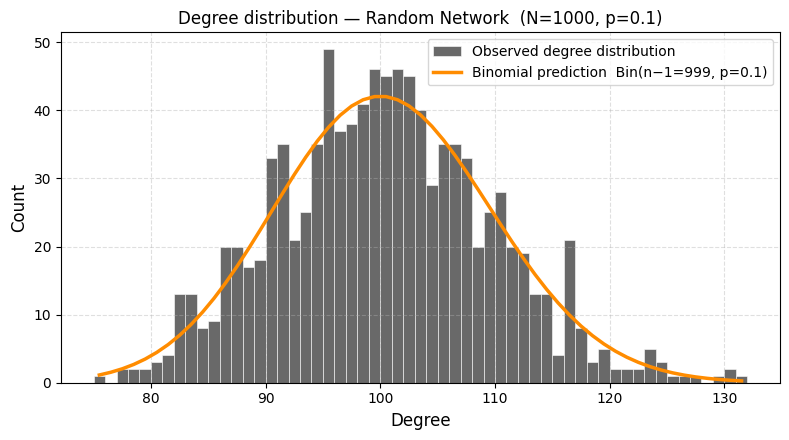

In [5]:
# --- Parameters for the binomial prediction ---
# Local variables:
#   n_trials  — number of possible partners per node = n - 1
#   p_edge    — probability of each edge = wiring_prob
#   k_values  — the degree values to evaluate the PMF over
n_trials = NUM_NODES - 1
p_edge   = WIRING_PROB

# Range of degree values to plot: from observed min to observed max.
k_values = np.arange(min(degrees), max(degrees) + 1)

# Binomial PMF: probability of having exactly k edges.
# Multiply by NUM_NODES to convert probability → expected count of nodes.
# This lets us overlay it directly on the count histogram.
expected_counts = NUM_NODES * binom.pmf(k_values, n=n_trials, p=p_edge)

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 4.5))

# Histogram of observed degree counts  (replicates NetLogo degree distribution plot).
ax.hist(
    degrees,
    bins=range(min(degrees), max(degrees) + 2),
    color='dimgray',
    edgecolor='white',
    linewidth=0.4,
    label='Observed degree distribution'
)

# Predicted binomial distribution overlay  (orange curve in Figure 9.5).
ax.plot(
    k_values + 0.5,   # shift by 0.5 to align with histogram bin centers
    expected_counts,
    color='darkorange',
    linewidth=2.5,
    label=f'Binomial prediction  Bin(n−1={n_trials}, p={p_edge})'
)

ax.set_xlabel('Degree', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title(
    f'Degree distribution — Random Network  (N={NUM_NODES}, p={WIRING_PROB})',
    fontsize=12
)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## 5. Visualizing a Small Random Network

With 1000 nodes the network is too dense to visualize meaningfully.
We build a small version (same parameters as Figure 9.5 in spirit,
but with N=30) to inspect the structure visually.

Unlike the ring lattice, nodes do **not** need to be arranged in a circle
here — a spring layout (`kamada_kawai`) will naturally spread the nodes
in a way that reflects the network structure.

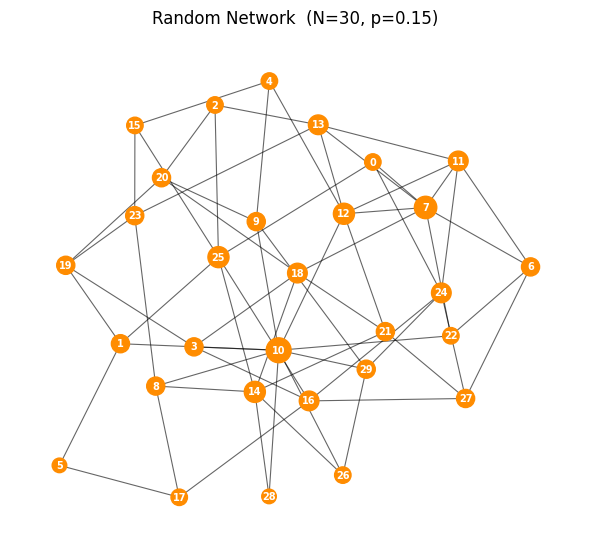

In [6]:
# Build a small random network for visual inspection.
# Local variables: G_small, pos, node_sizes.
G_small = make_random_network(num_nodes=30, wiring_prob=0.15, seed=7)

# Layout: Kamada-Kawai minimizes edge crossings — good for general graphs.
# (For the ring lattice we used circular_layout; here that would be misleading.)
pos = nx.kamada_kawai_layout(G_small)

# Scale node size proportionally to degree — higher-degree nodes appear larger,
# making the degree heterogeneity immediately visible.
node_sizes = [50 + 30 * G_small.degree(n) for n in G_small.nodes()]

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Random Network  (N=30, p=0.15)', fontsize=12, pad=10)

nx.draw_networkx_edges(G_small, pos, edge_color='black', width=0.8, alpha=0.6, ax=ax)
nx.draw_networkx_nodes(G_small, pos, node_color='darkorange',
                       node_size=node_sizes, ax=ax)
nx.draw_networkx_labels(G_small, pos, font_color='white',
                        font_size=7, font_weight='bold', ax=ax)

plt.tight_layout()
plt.show()

## 6. NetworkX Shortcut — `gnp_random_graph()`

Our manual implementation above is a direct translation of the NetLogo
code and is the right approach for learning. In practice, NetworkX has a
built-in G(n, p) generator that does exactly the same thing — and is
much faster for large networks because it uses a vectorized algorithm.

It's good to know both exist.

In [7]:
# NetworkX built-in G(n, p) generator.
# Produces statistically identical results to our manual implementation.
G_nx = nx.gnp_random_graph(n=NUM_NODES, p=WIRING_PROB, seed=SEED)

degrees_nx = [d for _, d in G_nx.degree()]
print("Using nx.gnp_random_graph():")
print(f"  Nodes : {G_nx.number_of_nodes()}")
print(f"  Edges : {G_nx.number_of_edges()}")
print(f"  Avg degree : {np.mean(degrees_nx):.2f}")

Using nx.gnp_random_graph():
  Nodes : 1000
  Edges : 49929
  Avg degree : 99.86


## 7. Key Network Metrics

In section 9.3.3, the small-world network is positioned as a middle ground
between the **high clustering / long paths** of a lattice and the
**low clustering / short paths** of a random network.

Here we confirm that a random network truly has those properties.

In [8]:
def network_metrics(G, label=""):
    """
    Print key structural metrics for a network.

    Uses only the largest connected component to ensure average path length
    is well-defined (path length is infinite between disconnected nodes).

    Parameters
    ----------
    G     : nx.Graph
    label : str — optional label printed in the header
    """
    # For sparse random networks, some nodes may be isolated (degree 0).
    # Average path length is only defined within connected components.
    # We compute it on the largest connected component (LCC).
    # Local variable: lcc — the largest connected component as a subgraph.
    lcc = G.subgraph(
        max(nx.connected_components(G), key=len)
    ).copy()

    degrees   = [d for _, d in G.degree()]
    avg_deg   = np.mean(degrees)
    density   = nx.density(G)
    avg_path  = nx.average_shortest_path_length(lcc)   # on LCC only
    clustering = nx.average_clustering(G)

    header = f"=== {label} ==" if label else "=" * 30
    print(header)
    print(f"  Nodes in LCC          : {lcc.number_of_nodes()} / {G.number_of_nodes()}")
    print(f"  Average degree ⟨k⟩    : {avg_deg:.3f}")
    print(f"  Network density ρ     : {density:.5f}")
    print(f"  Avg path length L     : {avg_path:.4f}   (on LCC)")
    print(f"  Clustering coeff. C   : {clustering:.4f}")


# Use a smaller network so average path length computes in reasonable time.
G_medium = make_random_network(num_nodes=200, wiring_prob=0.05, seed=SEED)
network_metrics(G_medium, label=f"Random Network  N=200, p=0.05")

=== Random Network  N=200, p=0.05 ==
  Nodes in LCC          : 200 / 200
  Average degree ⟨k⟩    : 9.840
  Network density ρ     : 0.04945
  Avg path length L     : 2.5609   (on LCC)
  Clustering coeff. C   : 0.0465


## 8. Comparing Random Network vs. Ring Lattice

This is the contrast that sets up the small-world network in section 9.3:
a random network has **short paths but low clustering**;
a ring lattice has **long paths but high clustering**.

We build both with matched average degree for a fair comparison.

In [9]:
# Import the ring lattice builder from the previous notebook.
# (Defined inline here for self-containedness.)
def make_ring_lattice(num_nodes, degree):
    """Build a ring lattice (from ch9_ring_network.ipynb)."""
    if degree >= num_nodes:
        degree = num_nodes - 1
    G = nx.Graph()
    G.add_nodes_from(range(num_nodes))
    for n in range(num_nodes):
        for k in range(1, degree // 2 + 1):
            G.add_edge(n, (n + k) % num_nodes)
    return G


# --- Setup: matched parameters ---
N   = 100   # number of nodes (small enough for fast path length computation)
K   = 6     # target average degree
p   = K / (N - 1)   # wiring_prob that gives expected avg degree = K

# Build both networks.
G_lattice = make_ring_lattice(num_nodes=N, degree=K)
G_random  = make_random_network(num_nodes=N, wiring_prob=p, seed=SEED)

# Print metrics side by side.
network_metrics(G_lattice, label=f"Ring Lattice    N={N}, k={K}")
print()
network_metrics(G_random,  label=f"Random Network  N={N}, p={p:.4f}")
print()
print("Interpretation:")
print("  The ring lattice has HIGH clustering and LONG average path length.")
print("  The random network has LOW clustering and SHORT average path length.")
print("  Small-world networks (section 9.3.3) achieve BOTH short paths AND high clustering.")

=== Ring Lattice    N=100, k=6 ==
  Nodes in LCC          : 100 / 100
  Average degree ⟨k⟩    : 6.000
  Network density ρ     : 0.06061
  Avg path length L     : 8.7576   (on LCC)
  Clustering coeff. C   : 0.6000

=== Random Network  N=100, p=0.0606 ==
  Nodes in LCC          : 99 / 100
  Average degree ⟨k⟩    : 5.860
  Network density ρ     : 0.05919
  Avg path length L     : 2.7712   (on LCC)
  Clustering coeff. C   : 0.0487

Interpretation:
  The ring lattice has HIGH clustering and LONG average path length.
  The random network has LOW clustering and SHORT average path length.
  Small-world networks (section 9.3.3) achieve BOTH short paths AND high clustering.


## 9. Effect of Wiring Probability on Network Structure

The NetLogo interface lets you drag `wiring-prob` and re-wire to see
how the degree distribution changes. Here we do this systematically:
we sweep over values of `p` and track how average degree, clustering,
and average path length change together.

This also previews the logic behind Figure 9.9 in the book.

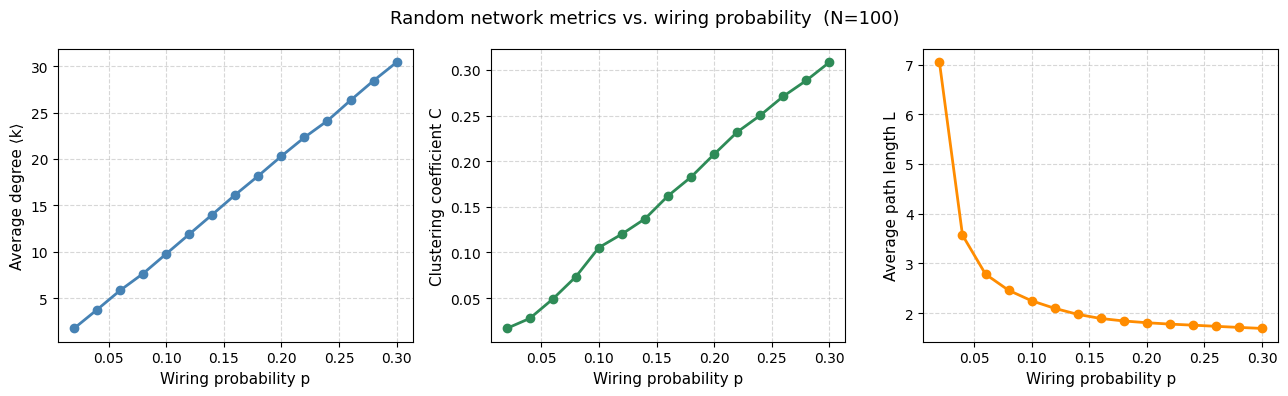

In [10]:
# --- Parameter sweep over wiring_prob ---
# Local variables: p_values, results.
N_sweep  = 100   # fix network size
p_values = np.linspace(0.02, 0.3, 15)   # range of wiring probabilities

results = []
for p in p_values:
    Gp = make_random_network(num_nodes=N_sweep, wiring_prob=p, seed=SEED)
    lcc = Gp.subgraph(max(nx.connected_components(Gp), key=len)).copy()
    results.append({
        'p'           : p,
        'avg_degree'  : np.mean([d for _, d in Gp.degree()]),
        'clustering'  : nx.average_clustering(Gp),
        'path_length' : nx.average_shortest_path_length(lcc),
    })

# Unpack results.
ps           = [r['p']            for r in results]
avg_degrees  = [r['avg_degree']   for r in results]
clusterings  = [r['clustering']   for r in results]
path_lengths = [r['path_length']  for r in results]

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle(f'Random network metrics vs. wiring probability  (N={N_sweep})', fontsize=13)

specs = [
    (avg_degrees,  'Average degree ⟨k⟩',        'steelblue'),
    (clusterings,  'Clustering coefficient C',   'seagreen'),
    (path_lengths, 'Average path length L',      'darkorange'),
]

for ax, (values, ylabel, color) in zip(axes, specs):
    ax.plot(ps, values, 'o-', color=color, lw=2, markersize=6)
    ax.set_xlabel('Wiring probability p', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### What do these plots show?

- **Average degree** rises linearly with `p` — exactly as the formula ⟨k⟩ = p(n−1) predicts.
- **Clustering coefficient** also rises with `p`. In a random network, C ≈ p: the probability that two of your neighbors are also connected to each other is the same as the probability any two nodes are connected.
- **Average path length** *decreases* as `p` increases — more edges mean more shortcuts.

The key contrast with a ring lattice: in a lattice, clustering stays high and roughly *constant* as degree increases (because the local structure is always regular). In a random network, clustering and path length both track `p` together. There is no regime where clustering is high but path length is short — that sweet spot belongs to small-world networks (section 9.3.3).